# Graded orientation profile fitting (refloxide)

This notebook walks through the **book-ended** ZnPc orientation and density profile used in `fit_profile.ipynb`, but routes reflectivity through **refloxide** (`utils.models` patches `pyref.fitting`).

**Stack (single energy, 283.7 eV):** vacuum | graded book-ended film | SiO$_2$ | Si

**Compared to three-slab DFT template:** surf + bulk + interface `UniTensorSLD` slabs are collapsed into one `EnergyBookendedOrientationDensityProfile` (Rust OOC interpolation, lab-frame uniaxial kernel).

Run from the **refl-analysis** project root so `utils` and data paths resolve.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from utils import read_fit, read_ooc, read_xrr
from utils.models import (
    AnisotropyObjective,
    CurveFitter,
    ReflectModel,
    Transform,
    configure_refloxide_fitting,
)
from utils.refloxide_profile import model_bookended_refloxide

configure_refloxide_fitting(use_rust=True, parallel=False)

In [2]:
oocs = read_ooc("dft.csv", material="znpc")
data = read_xrr("reflectivity_data", material="znpc", source="hub")
dft_fit = read_fit("dft/dft_en_offset_new2.pkl", material="znpc", source="local")

ENERGY_FIT = 283.7
NUM_SLABS_FIT = 24
NUM_SLABS_PLOT = 100

list(data.keys())

['282.9',
 '281.6',
 '289.0',
 '283.5',
 '281.4',
 '282.0',
 '282.3',
 '275.0',
 '284.2',
 '282.7',
 '285.1',
 '281.2',
 '287.0',
 '283.3',
 '281.8',
 '280.0',
 '283.7',
 '282.5',
 '250.0',
 '283.1',
 '281.0']

In [3]:
def en_access(energy: float, fit_bundle):
    """Return the objective in a saved multi-energy fit at ``energy`` (eV)."""
    return next(o for o in fit_bundle.objectives if o.model.energy == float(energy))


def model_graded(
    energy: float,
    *,
    num_slabs: int = NUM_SLABS_FIT,
    mesh_constant: float = 0.1,
):
    """Book-ended graded film via refloxide (fused Rust path after ``utils.models`` import)."""
    template = en_access(float(energy), dft_fit)
    return model_bookended_refloxide(
        template,
        oocs,
        float(energy),
        num_slabs=num_slabs,
        mesh_constant=mesh_constant,
        interp="linear",
    )


template_obj = en_access(ENERGY_FIT, dft_fit)
template_obj.model.energy


np.float64(283.7)

## Stack layout

| Index | Component                                                                                        |
| ----- | ------------------------------------------------------------------------------------------------ |
| 0     | Vacuum                                                                                           |
| 1     | `EnergyBookendedOrientationDensityProfile` (graded $\alpha(z)$, $\rho(z)$; fused Rust evaluator) |
| 2     | SiO$_2$ (fixed in this demo)                                                                     |
| 3     | Si substrate                                                                                     |

The film uses exponential book-ends toward vacuum ($\tau_\mathrm{vac}$) and toward the interface ($\tau_\mathrm{Si}$). Importing `utils.models` patches `pyref.fitting` and routes qualifying book-ended stacks through the fused kernel when `dq == 0`.


In [4]:
structure_fit = model_graded(ENERGY_FIT, num_slabs=NUM_SLABS_FIT)
structure_plot = model_graded(ENERGY_FIT, num_slabs=NUM_SLABS_PLOT)

znpc = structure_fit.components[1]
znpc.cache_ooc_at(ENERGY_FIT)
znpc

In [5]:
znpc.total_thick.setp(vary=True, bounds=(160, 210))
znpc.surface_roughness.setp(vary=True, bounds=(0, 10))
znpc.tau_si.setp(vary=True, bounds=(0.5, 15))
znpc.tau_vac.setp(vary=True, bounds=(0.5, 30))
znpc.alpha_bulk.setp(vary=True, bounds=(0, np.pi / 2))
znpc.density_bulk.setp(vary=False, bounds=(1.0, 2.5))
znpc.density_si.setp(vary=None, constraint=znpc.density_bulk)
znpc.density_vac.setp(vary=None, constraint=znpc.density_bulk)

sio2 = structure_fit.components[2]
sio2.thick.setp(vary=False)
sio2.rough.setp(vary=False)
sio2.sld.density.setp(vary=False)

si = structure_fit.components[3]
si.thick.setp(vary=False)
si.rough.setp(vary=False)
si.sld.density.setp(vary=False)

[p.name for p in structure_fit.parameters.varying_parameters()]

['energy_offset',
 'total_thick',
 'surface_roughness',
 'tau_si',
 'tau_vac',
 'alpha_bulk']

In [6]:
dft_obj = en_access(ENERGY_FIT, dft_fit)
dft_model = dft_obj.model

refl = ReflectModel(structure_fit, energy=ENERGY_FIT, pol="sp")
refl.scale_s.setp(value=dft_model.scale_s.value, vary=True, bounds=(0.5, 2.1))
refl.scale_p.setp(value=dft_model.scale_p.value, vary=True, bounds=(0.5, 2.1))
refl.theta_offset_s.setp(value=dft_model.theta_offset_s.value, vary=True, bounds=(-1.5, 1.5))
refl.theta_offset_p.setp(value=dft_model.theta_offset_p.value, vary=True, bounds=(-1.5, 1.5))
refl.energy_offset.setp(value=dft_model.energy_offset.value, vary=False)
refl.bkg.setp(value=0, vary=False)

refl

ReflectModel(Structure(components=[Slab(Parameter(value=0.0, name='Vacuum_283.7_thick', vary=False, bounds=Interval(lb=0.0, ub=0.0), constraint=None), MaterialSLD('', Parameter(value=0.0, name='Vacuum_283.7_rho', vary=False, bounds=Interval(lb=0.0, ub=0.0), constraint=None),energy=np.float64(283.7),  name='Vacuum_283.7'), Parameter(value=0.0, name='Vacuum_283.7_rough', vary=False, bounds=Interval(lb=0.0, ub=0.0), constraint=None), name='Vacuum_283.7',, <refloxide.pxr.energy.bookended.BookendedOrientationProfile object at 0x122ce8800>, Slab(Parameter(value=6.879413391765527, name='Oxide_283.7_thick', vary=False, bounds=Interval(lb=0.0, ub=20.0), constraint=None), MaterialSLD('SiO2', Parameter(value=1.921213147656673, name='Oxide_283.7_rho', vary=False, bounds=Interval(lb=1.0, ub=2.47), constraint=None),energy=np.float64(283.7),  name='Oxide_283.7'), Parameter(value=8.126660536306115, name='Oxide_283.7_rough', vary=False, bounds=Interval(lb=0.0, ub=25.0), constraint=None), name='Oxide_28

-6.152391917535798 9
________________________________________________________________________________
Parameters:      None      
<Parameter:   'scale_s'   , value=1.4          , bounds=[0.5, 2.1]>
<Parameter:   'scale_p'   , value=1.34353          , bounds=[0.5, 2.1]>
<Parameter:'theta_offset_s', value=0.0284354          , bounds=[-1.5, 1.5]>
<Parameter:'theta_offset_p', value=-0.227922          , bounds=[-1.5, 1.5]>
<Parameter: 'total_thick' , value=199.59          , bounds=[160.0, 210.0]>
<Parameter:'surface_roughness', value=7.05602          , bounds=[0.0, 10.0]>
<Parameter:   'tau_si'    , value=10.7048          , bounds=[0.5, 15.0]>
<Parameter:   'tau_vac'   , value=8.93351          , bounds=[0.5, 30.0]>
<Parameter: 'alpha_bulk'  , value=1.21368          , bounds=[0.0, 1.5707963267948966]>


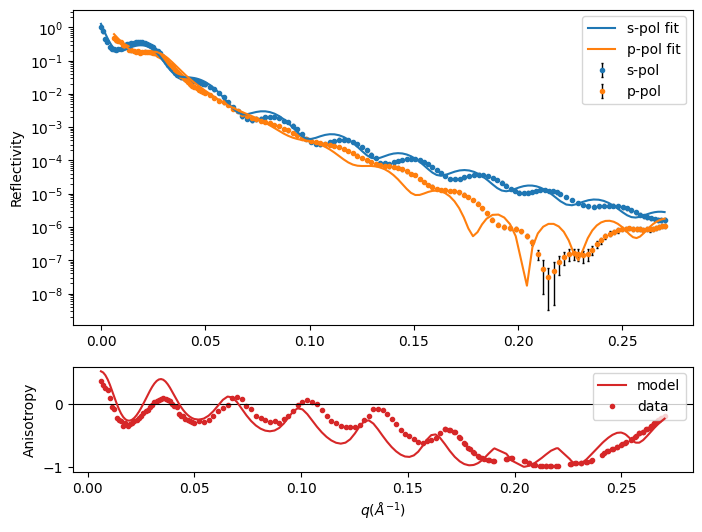

In [7]:
objective = AnisotropyObjective(
    refl,
    data[str(ENERGY_FIT)],
    logp_anisotropy_weight=0.5,
    transform=Transform("logY"),
)

print(objective.logl(), len(objective.varying_parameters()))
objective.plot()
print(objective.varying_parameters())

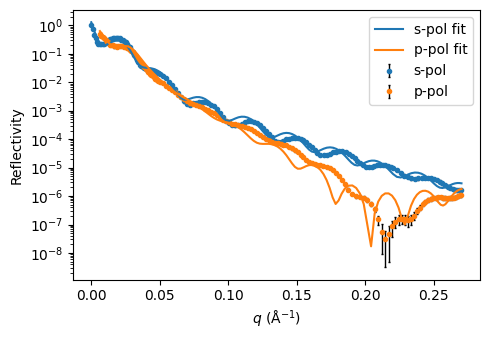

In [8]:
fig, ax = plt.subplots(figsize=(5, 3.5))
objective.plot(ax=ax, show_anisotropy=False)
ax.set_yscale("log")
ax.set_xlabel(r"$q$ (Å$^{-1}$)")
fig.tight_layout()
plt.show()

## Refloxide kernel

`import utils.models` calls `configure_refloxide_fitting(parallel=False)`. Each `logl` evaluation uses the Rust uniaxial TJF path with **no inner Rayon pool**, so `ReflectModel` maps `pol='s'/'p'` to kernel `R_ss`/`R_pp` via `reflectmodel_layout`.

After pulling refloxide changes, reinstall into this env and rebuild the extension:

```bash
cd ../refloxide && make develop
cd ../refl-analysis && uv sync --reinstall-package refloxide
```


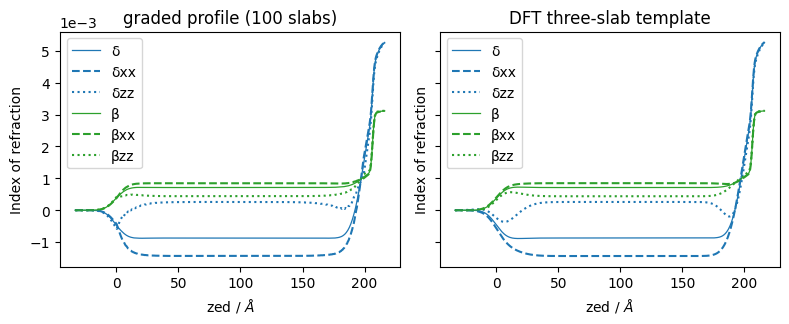

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)

structure_plot.plot(ax=axes[0])
axes[0].set_title(f"graded profile ({NUM_SLABS_PLOT} slabs)")

dft_obj.model.structure.plot(ax=axes[1])
axes[1].set_title("DFT three-slab template")

fig.tight_layout()
plt.show()

## Parallelism: worker pools vs vectorization

**Today:** `CurveFitter` / differential evolution uses a **process pool** (`workers=8`). The reflectivity kernel stays **single-threaded** (`parallel=False`) to avoid nested Rayon oversubscription (pool workers × Rayon threads).

**Later (not implemented here):** batch or vectorize `logl` so many $q$ points, energies, or walkers share one Rust call without turning Rayon on inside each pool worker. Candidates:

- `refloxide.pxr.plugin.batched_global.BatchedGlobalObjective` for multi-channel / multi-energy objectives in one pass (`parallel_kernels=False` under pools)
- batched $q$ grids in the uniaxial kernel for emcee / dynesty likelihood loops

We keep this notebook on the simple single-energy path until that vectorized API exists.

**Parallelism:** call `patch_pyref(parallel=False)` (default in `utils.models`) so emcee/refnx worker pools are not oversubscribed; the fused book-ended kernel is already fast single-threaded.


In [ ]:
fitter = CurveFitter(objective)
fitter.fit(
    method="differential_evolution",
    workers=8,
    updating="deferred",
    maxiter=50,
    polish=False,
    x0 = [p.value for p in objective.varying_parameters()]
)
objective.plot()
plt.show()

1.4996704976426916: : 13it [00:47,  3.15s/it]

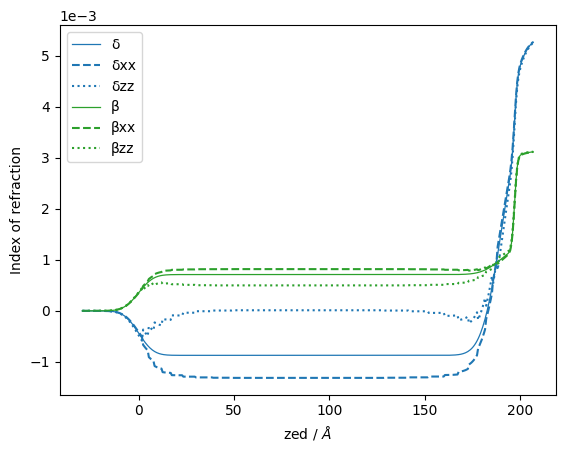

In [11]:
objective.model.structure.plot()
plt.show()

In [12]:
varying = objective.varying_parameters()
len(varying), varying[:8]

(7,
 [Parameter(value=1.679502755933503, name='scale_s', vary=True, bounds=Interval(lb=0.5, ub=2.1), constraint=None),
  Parameter(value=1.395474447223583, name='scale_p', vary=True, bounds=Interval(lb=0.5, ub=2.1), constraint=None),
  Parameter(value=0.2317849899075628, name='theta_offset_s', vary=True, bounds=Interval(lb=-1.5, ub=1.5), constraint=None),
  Parameter(value=-0.2181456289473508, name='theta_offset_p', vary=True, bounds=Interval(lb=-1.5, ub=1.5), constraint=None),
  Parameter(value=190.17327585341224, name='total_thick', vary=True, bounds=Interval(lb=160.0, ub=210.0), constraint=None),
  Parameter(value=6.130103731770119, name='surface_roughness', vary=True, bounds=Interval(lb=0.0, ub=10.0), constraint=None),
  Parameter(value=1.1484299219526486, name='alpha_bulk', vary=True, bounds=Interval(lb=0.0, ub=1.5707963267948966), constraint=None)])

-0.4560346756376923: : 50it [01:11,  1.43s/it] 


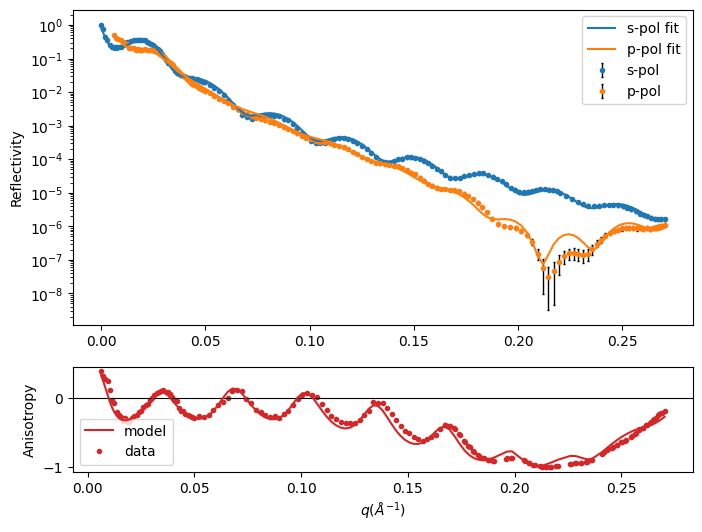

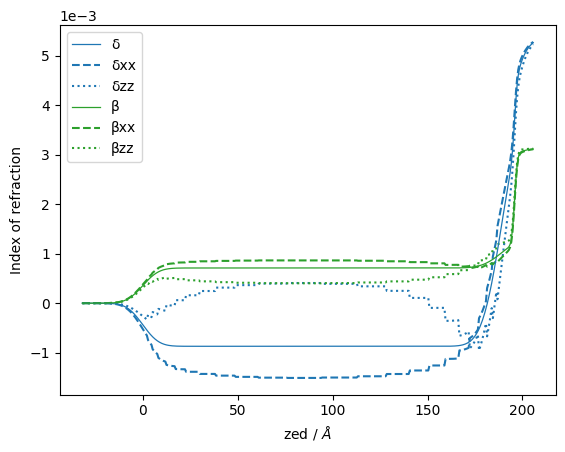

In [14]:
# Open up the alpha parameters
objective.model.structure.components[1].tau_si.setp(vary=True, bounds=(0.5, 25))
objective.model.structure.components[1].tau_vac.setp(vary=True, bounds=(0.5, 25))
objective.model.structure.components[1].alpha_si.setp(vary=True, bounds=(0, np.pi / 4))
objective.model.structure.components[1].alpha_vac.setp(vary=True, bounds=(0, np.pi / 2))

fitter = CurveFitter(objective)
fitter.fit(
    method="differential_evolution",
    workers=8,
    updating="deferred",
    maxiter=50,
    polish=False,
    #x0 = [p.value for p in objective.varying_parameters()]
)

objective.plot()
plt.show()
objective.model.structure.plot()
plt.show()

In [ ]:
print(fitter.objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:   'scale_s'   , value=1.5402 +/- 0.0187, bounds=[0.5, 2.1]>
<Parameter:   'scale_p'   , value=1.48178 +/- 0.0108, bounds=[0.5, 2.1]>
<Parameter:'theta_offset_s', value=0.332864 +/- 0.0157, bounds=[-1.5, 1.5]>
<Parameter:'theta_offset_p', value=0.345008 +/- 0.0254, bounds=[-1.5, 1.5]>
<Parameter: 'total_thick' , value=189.624 +/- 0.126, bounds=[160.0, 210.0]>
<Parameter:'surface_roughness', value=7.88537 +/- 0.154, bounds=[0.0, 10.0]>
<Parameter:   'tau_si'    , value=21.5117          , bounds=[0.5, 25.0]>
<Parameter:   'tau_vac'   , value=23.1935          , bounds=[0.5, 25.0]>
<Parameter: 'alpha_bulk'  , value=1.27969 +/- 0.00207, bounds=[0.0, 1.5707963267948966]>
<Parameter:  'alpha_si'   , value=0.590826          , bounds=[0.0, 0.7853981633974483]>
<Parameter:  'alpha_vac'  , value=1.02962          , bounds=[0.0, 1.5707963267948966]>


0it [00:00, ?it/s]

-0.5544176002998139: : 50it [02:22,  2.85s/it]


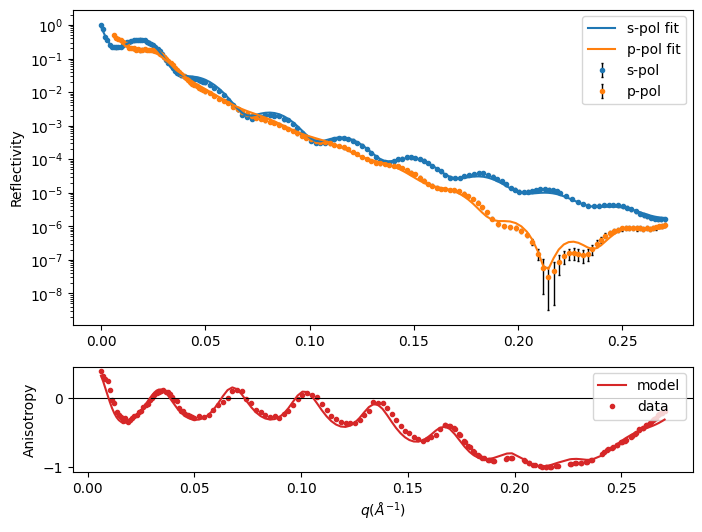

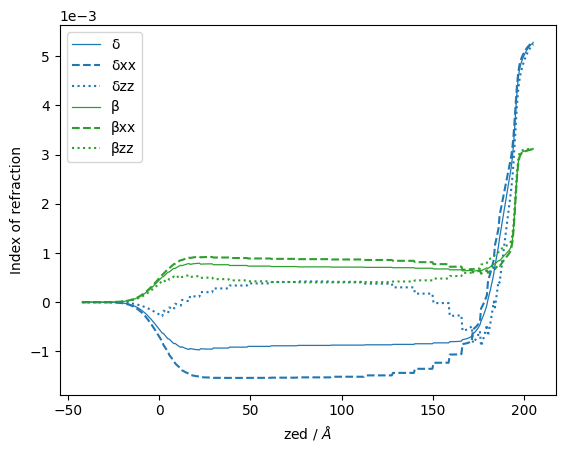

________________________________________________________________________________
Parameters:      None      
<Parameter:   'scale_s'   , value=1.47085 +/- 0.0187, bounds=[0.5, 2.1]>
<Parameter:   'scale_p'   , value=1.48894 +/- 0.0108, bounds=[0.5, 2.1]>
<Parameter:'theta_offset_s', value=0.29785 +/- 0.0157, bounds=[-1.5, 1.5]>
<Parameter:'theta_offset_p', value=0.299886 +/- 0.0254, bounds=[-1.5, 1.5]>
<Parameter: 'total_thick' , value=188.414 +/- 0.126, bounds=[160.0, 210.0]>
<Parameter:'surface_roughness', value=9.29608 +/- 0.154, bounds=[0.0, 10.0]>
<Parameter: 'density_si'  , value=1.12844          , bounds=[0.5, 2.5]>
<Parameter: 'density_vac' , value=2.08979          , bounds=[0.5, 2.5]>
<Parameter:   'tau_si'    , value=18.9416          , bounds=[0.5, 25.0]>
<Parameter:   'tau_vac'   , value=24.6743          , bounds=[0.5, 25.0]>
<Parameter: 'alpha_bulk'  , value=1.27218 +/- 0.00207, bounds=[0.0, 1.5707963267948966]>
<Parameter:  'alpha_si'   , value=0.48519          , bounds=[0

In [ ]:
objective.model.structure.components[1].density_bulk.setp(vary=False, bounds=(1, 2.5))
objective.model.structure.components[1].density_si.constraint = None
objective.model.structure.components[1].density_si.setp(vary=True, bounds=(0.5, 2.5))
objective.model.structure.components[1].density_vac.constraint = None
objective.model.structure.components[1].density_vac.setp(vary=True, bounds=(0.5, 2.5))

fitter = CurveFitter(objective)
fitter.fit(
    method="differential_evolution",
    workers=8,
    updating="deferred",
    maxiter=50,
    polish=True,
    x0 = [p.value for p in objective.varying_parameters()]
)

objective.plot()
plt.show()
objective.model.structure.plot()
plt.show()
print(fitter.objective.varying_parameters())

In [15]:
# Export this fit to a pickle of the DFT models
import pickle

from utils import models_root

with open(
    models_root / "xrr" / "znpc" / "graded" / "graded_fit.pkl",
    "wb",
) as f:
    pickle.dump(objective, f)